# Experiment 3 — Width ($m$) and Depth ($L$) in the Large-Sample Complex Regime

Extracts insights and figures from `exp_width_depth_complex.csv`. The notebook is organised
around the four questions the experiment was built to answer:

1. **Complexity verification** — is each dataset actually complex (MLP $>$ exact RBF-SVM), and at
   what $n$ does exact RBF-SVM stop being feasible? (`phase=complexity_probe`, `reference_rbf`)
2. **Width** — does $m>1$ help, and does the benefit fade as $n$ grows? (`phase=architecture`)
3. **Depth and its interaction with width** — does adding layers help, on which task, and does the
   depth benefit grow with $m$?
4. **Headline** — does the architecture beat its same-kernel flat baseline, and where?

Conclusions are left to be read from the tables and figures — nothing is pre-written.

In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
pd.set_option("display.width",200); pd.set_option("display.max_columns",60)
mpl.rcParams.update({"figure.dpi":110,"font.size":10,"axes.grid":True,"grid.alpha":0.3})
CSV = "../results/exp_width_depth_complex.csv"   # adjust if needed

## 1. Load and tag

Splits the rows by `phase`, coerces numerics, and derives $m$/$L$ from the model string for the
architecture rows. Picks the best available metric: macro-F1 for multiclass where present, else accuracy.

In [4]:
df = pd.read_csv(CSV)
df.columns = [c.strip() for c in df.columns]
for c in ["n_total","n_train","n_test","d","n_classes","m","L","P","seed","acc","macro_f1","train_time_s"]:
    if c in df: df[c] = pd.to_numeric(df[c], errors="coerce")

# derive m/L from model where missing (e.g. arch_m10_L2)
mm = df["model"].astype(str).str.extract(r"_m(\d+)_L(\d+)")
df["m"] = df["m"].fillna(pd.to_numeric(mm[0], errors="coerce"))
df["L"] = df["L"].fillna(pd.to_numeric(mm[1], errors="coerce"))

print("rows:", len(df))
print("phases:", df.phase.value_counts().to_dict())
print("datasets:", df.dataset.unique().tolist())
print("tasks:", df.groupby("dataset").task.first().to_dict())
print("m values:", sorted(df.m.dropna().unique().tolist()))
print("L values:", sorted(df.L.dropna().unique().tolist()))
print("metrics present: acc", df.acc.notna().any(), "| macro_f1", df.macro_f1.notna().any())
df.head(3)

rows: 957
phases: {'architecture': 783, 'reference_flat': 69, 'reference_rbf': 69, 'complexity_probe': 36}
datasets: ['HIGGS', 'SUSY', 'MiniBooNE', 'CoverType', 'Jannis', 'MNIST']
tasks: {'CoverType': 'multiclass', 'HIGGS': 'binary', 'Jannis': 'multiclass', 'MNIST': 'multiclass', 'MiniBooNE': 'binary', 'SUSY': 'binary'}
m values: [0.0, 1.0, 5.0, 10.0, 20.0]
L values: [0.0, 1.0, 2.0, 3.0]
metrics present: acc True | macro_f1 True


,exp_id,phase,dataset,task,n_total,n_train,n_test,d,n_classes,model,kernel,m,L,P,feeding,seed,acc,macro_f1,train_time_s,rbf_feasible,timestamp
0,exp_width_depth_complex,complexity_probe,HIGGS,binary,10000,10000,20000,28,2,MLP_200x200,-,NaN,NaN,NaN,NaN,0,0.6637,NaN,3.59,NaN,2026-06-19T00:15:19.134465
1,exp_width_depth_complex,complexity_probe,HIGGS,binary,10000,10000,20000,28,2,RBF_SVM_exact,rbf,NaN,NaN,NaN,NaN,0,0.6685,NaN,2.83,yes,2026-06-19T00:15:28.630775
2,exp_width_depth_complex,complexity_probe,HIGGS,binary,10000,10000,20000,28,2,MLP_200x200,-,NaN,NaN,NaN,NaN,1,0.6696,NaN,3.44,NaN,2026-06-19T00:15:32.145604


In [5]:
# primary metric per row: macro_f1 for multiclass when available, else acc
df["metric"] = np.where((df.task=="multiclass") & df.macro_f1.notna(), df.macro_f1, df.acc)
df["metric_name"] = np.where((df.task=="multiclass") & df.macro_f1.notna(), "macro_F1", "accuracy")

def agg_seeds(d, keys):
    g = d.groupby(keys, dropna=False)["metric"].agg(["mean","std","size"]).reset_index()
    g["std"] = g["std"].fillna(0.0)
    return g

DATASET_ORDER = [x for x in ["HIGGS","SUSY","MiniBooNE","CoverType","Jannis","MNIST"]
                 if x in df.dataset.unique()]
TASK = df.groupby("dataset").task.first().to_dict()
IS_CONTROL = {"MNIST": True}   # the simple control
print("dataset order:", DATASET_ORDER)

dataset order: ['HIGGS', 'SUSY', 'MiniBooNE', 'CoverType', 'Jannis', 'MNIST']


## 2. Complexity verification & the kernel-feasibility wall

For each dataset, the MLP vs exact RBF-SVM margin at the probe size (the operational definition of
*complex*: MLP beats RBF by $>0.03$), and the largest $n$ at which exact RBF-SVM was still feasible.
This is what licenses calling a dataset complex, and documents the regime where exact kernels stop running.

In [6]:
# --- complexity probe: MLP vs RBF at probe n ---
probe = df[df.phase=="complexity_probe"]
rows=[]
for ds in DATASET_ORDER:
    g = probe[probe.dataset==ds]
    mlp = g[g.model.str.contains("MLP", case=False, na=False)]["metric"]
    rbf = g[g.model.str.contains("RBF", case=False, na=False)]["metric"]
    if len(mlp):
        n_probe = int(g.n_train.iloc[0])
        mlp_m = mlp.mean(); rbf_m = (rbf.mean() if len(rbf) else np.nan)
        margin = (mlp_m - rbf_m) if len(rbf) else np.nan
        rows.append(dict(dataset=ds, task=TASK[ds], n_probe=n_probe,
            MLP=round(mlp_m,4), RBF=(round(rbf_m,4) if len(rbf) else np.nan),
            margin=(round(margin,4) if margin==margin else np.nan),
            verdict=("complex" if (margin==margin and margin>0.03) else "not at this n")))
complexity = pd.DataFrame(rows)
print("Complexity probe (MLP - RBF at probe n; complex if margin>0.03):")
display(complexity)

# --- feasibility wall: largest n where exact RBF actually ran ---
rbf_runs = df[(df.phase.isin(["reference_rbf","complexity_probe"])) &
              (df.model.str.contains("RBF", case=False, na=False))]
wall=[]
for ds in DATASET_ORDER:
    g = rbf_runs[rbf_runs.dataset==ds]
    feasible = g[(g.rbf_feasible=="yes") | (g.acc.notna())]
    infeasible = g[g.rbf_feasible=="no"]
    wall.append(dict(dataset=ds,
        max_n_rbf_ran=(int(feasible.n_train.max()) if len(feasible) else None),
        min_n_rbf_infeasible=(int(infeasible.n_train.min()) if len(infeasible) else None)))
print("\nExact RBF-SVM feasibility wall (largest n it ran vs smallest n flagged infeasible):")
display(pd.DataFrame(wall))

Complexity probe (MLP - RBF at probe n; complex if margin>0.03):


,dataset,task,n_probe,MLP,RBF,margin,verdict
0,HIGGS,binary,10000,0.6663,0.6693,-0.0030,not at this n
1,SUSY,binary,10000,0.7976,0.7981,-0.0005,not at this n
2,MiniBooNE,binary,10000,0.9106,0.8763,0.0343,complex
3,CoverType,multiclass,10000,0.6585,0.4556,0.2029,complex
4,Jannis,multiclass,10000,0.4793,0.4850,-0.0057,not at this n
5,MNIST,multiclass,10000,0.9466,0.9390,0.0076,not at this n



Exact RBF-SVM feasibility wall (largest n it ran vs smallest n flagged infeasible):


,dataset,max_n_rbf_ran,min_n_rbf_infeasible
0,HIGGS,10000,50000
1,SUSY,10000,50000
2,MiniBooNE,10000,50000
3,CoverType,10000,50000
4,Jannis,10000,50000
5,MNIST,10000,50000


## 3. Width — does $m>1$ help, and does it fade with $n$?

For each (dataset, $n$), the best $m>1$ configuration (over $L$) against the $m=1$ baseline (best $L$).
`sig` flags a gain beyond one seed std. The plot shows the width gain vs $n$ per dataset.

In [7]:
arch = df[df.phase=="architecture"].copy()
A = agg_seeds(arch, ["dataset","n_train","m","L"])

def width_table():
    rows=[]
    for (ds,n),g in A.groupby(["dataset","n_train"]):
        m1 = g[g.m==1]; mgt = g[g.m>1]
        if m1.empty or mgt.empty: continue
        b1 = m1.loc[m1["mean"].idxmax()]; bm = mgt.loc[mgt["mean"].idxmax()]
        gain = bm["mean"]-b1["mean"]
        rows.append(dict(dataset=ds, task=TASK[ds], n=int(n),
            m1=round(b1["mean"],4), best_mgt=round(bm["mean"],4),
            best_m=int(bm.m), best_L=int(bm.L), gain=round(gain,4),
            sig=bool(gain > bm["std"])))
    return pd.DataFrame(rows).sort_values(["dataset","n"])
WT = width_table()
print("Width effect (best m>1 vs m=1):")
display(WT)

Width effect (best m>1 vs m=1):


,dataset,task,n,m1,best_mgt,best_m,best_L,gain,sig
0,CoverType,multiclass,2000,0.5368,0.5326,10,3,-0.0043,False
1,CoverType,multiclass,5000,0.6055,0.5904,5,3,-0.0151,False
2,CoverType,multiclass,50000,0.7327,0.7420,5,3,0.0093,True
3,CoverType,multiclass,100000,0.7377,0.7548,5,3,0.0170,True
4,HIGGS,binary,2000,0.5840,0.6293,10,1,0.0453,True
5,HIGGS,binary,5000,0.6153,0.6418,20,1,0.0264,True
6,HIGGS,binary,50000,0.6717,0.6711,5,1,-0.0006,False
7,HIGGS,binary,100000,0.6722,0.6736,20,1,0.0014,False
8,HIGGS,binary,200000,0.6759,0.6767,10,2,0.0008,False
9,Jannis,multiclass,2000,0.3981,0.4468,10,2,0.0487,True


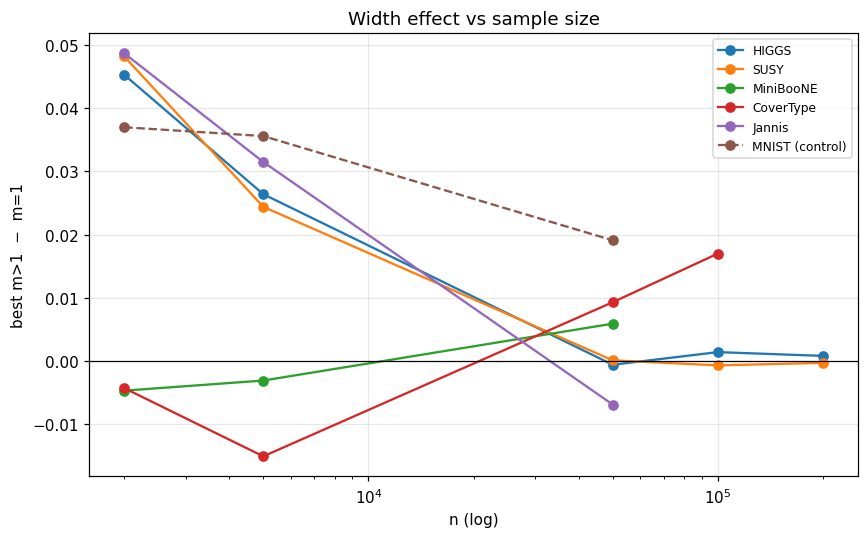

In [8]:
# Plot: width gain vs n, one line per dataset (control dashed)
fig,ax=plt.subplots(figsize=(8,5))
for ds in DATASET_ORDER:
    g=WT[WT.dataset==ds].sort_values("n")
    if g.empty: continue
    style="--" if IS_CONTROL.get(ds) else "-"
    ax.plot(g.n,g.gain,marker="o",ls=style,label=ds+(" (control)" if IS_CONTROL.get(ds) else ""))
ax.axhline(0,color="k",lw=.8)
ax.set_xscale("log"); ax.set_xlabel("n (log)"); ax.set_ylabel("best m>1  −  m=1")
ax.set_title("Width effect vs sample size"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("fig_width_gain.png",bbox_inches="tight"); plt.show()

## 4. Depth and its interaction with width

The core question. For each (dataset, $m$, $n$), the gain from $L=1$ to the best $L$. Then summarised
two ways: by **task** (binary physics vs multiclass — the split flagged as the key risk), and by **$m$**
(does the depth benefit grow with width?). The interaction heatmap shows depth gain across the $m\times L$
grid per dataset.

In [9]:
# depth gain per (dataset, m, n): best L minus L=1
piv = A.pivot_table(index=["dataset","m","n_train"], columns="L", values="mean")
drows=[]
for idx,r in piv.iterrows():
    ds,m,n = idx
    if 1 not in r or pd.isna(r.get(1,np.nan)): continue
    Ls=[L for L in r.index if pd.notna(r.get(L,np.nan))]
    if len(Ls)<2: continue
    bestL=max(Ls,key=lambda L:r[L])
    drows.append(dict(dataset=ds, task=TASK[ds], m=int(m), n=int(n),
        L1=round(r[1],4), bestL=int(bestL), bestL_val=round(r[bestL],4),
        depth_gain=round(r[bestL]-r[1],4)))
DG = pd.DataFrame(drows)
print("=== depth gain by TASK (binary vs multiclass) ===")
display(DG.groupby("task")["depth_gain"].agg(["mean","median","max","count"]).round(4))
print("\n=== depth gain by DATASET ===")
display(DG.groupby("dataset")["depth_gain"].agg(["mean","median","max","count"]).round(4))
print("\n=== depth gain by WIDTH m (does depth scale with m?) ===")
display(DG.groupby("m")["depth_gain"].agg(["mean","median","count"]).round(4))

=== depth gain by TASK (binary vs multiclass) ===


,mean,median,max,count
task,,,,
binary,0.0004,0.0000,0.0030,49
multiclass,0.0204,0.0058,0.0815,38



=== depth gain by DATASET ===


,mean,median,max,count
dataset,,,,
CoverType,0.0437,0.0392,0.0815,15
HIGGS,0.0003,0.0000,0.0016,19
Jannis,0.0066,0.0027,0.0208,11
MNIST,0.0038,0.0031,0.0123,12
MiniBooNE,0.0009,0.0008,0.0030,11
SUSY,0.0002,0.0000,0.0019,19



=== depth gain by WIDTH m (does depth scale with m?) ===


,mean,median,count
m,,,
1,0.0045,0.0009,23
5,0.0109,0.0005,23
10,0.0108,0.0013,23
20,0.0106,0.0003,18


/tmp/ipykernel_854959/2577684779.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data,labels=order,showmeans=True,widths=0.5)


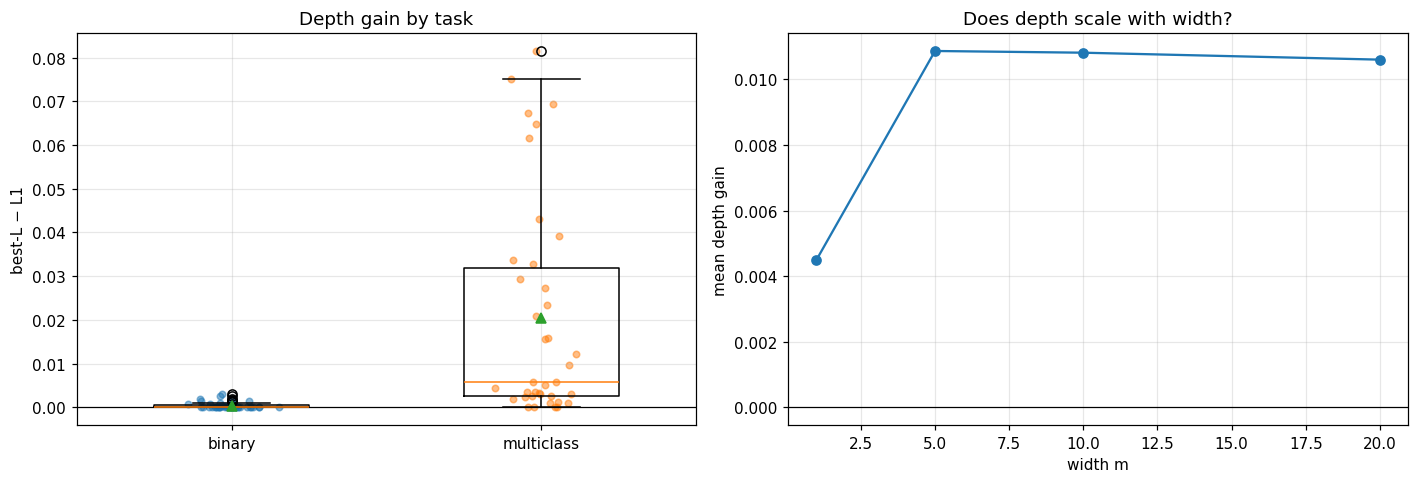

In [10]:
# Plot A: depth gain by task (box + strip) — the binary-vs-multiclass split
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
ax=axes[0]
order=[t for t in ["binary","multiclass"] if t in DG.task.unique()]
data=[DG[DG.task==t].depth_gain.values for t in order]
ax.axhline(0,color="k",lw=.8)
ax.boxplot(data,labels=order,showmeans=True,widths=0.5)
for i,t in enumerate(order):
    y=DG[DG.task==t].depth_gain.values; x=np.random.normal(i+1,0.05,len(y))
    ax.scatter(x,y,alpha=0.5,s=18)
ax.set_ylabel("best-L − L1"); ax.set_title("Depth gain by task")

# Plot B: depth gain vs m (does depth scale with width?)
ax=axes[1]
mg=DG.groupby("m")["depth_gain"].mean()
ax.axhline(0,color="k",lw=.8)
ax.plot(mg.index,mg.values,marker="o")
ax.set_xlabel("width m"); ax.set_ylabel("mean depth gain"); ax.set_title("Does depth scale with width?")
plt.tight_layout(); plt.savefig("fig_depth.png",bbox_inches="tight"); plt.show()

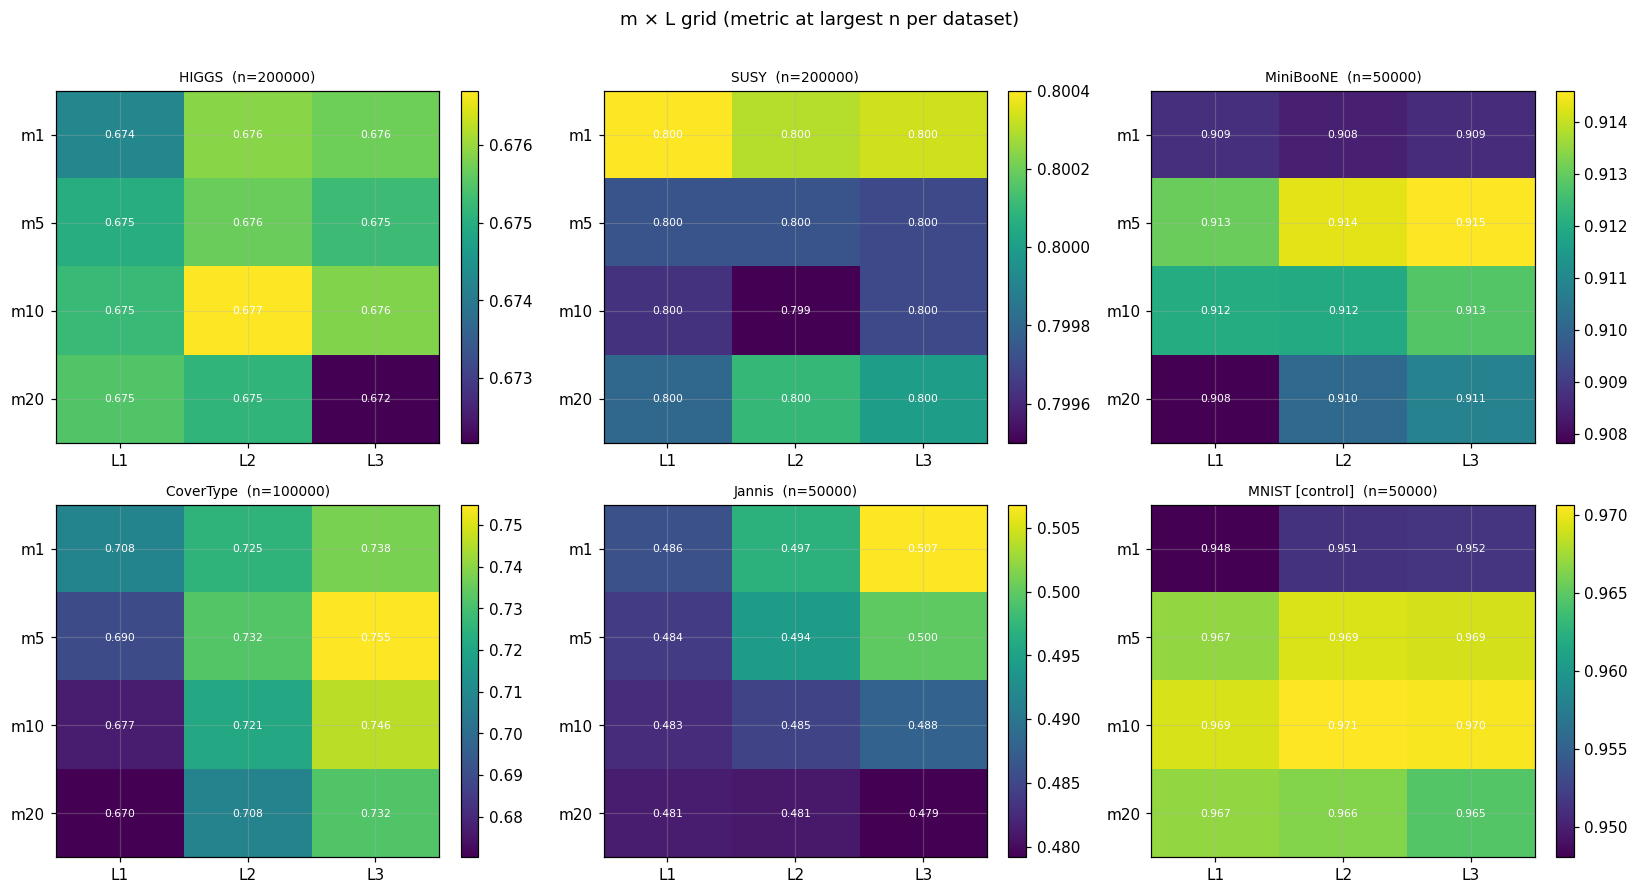

In [11]:
# Plot C: m x L interaction heatmaps, one panel per dataset (at its largest n)
ncol=3; nrow=int(np.ceil(len(DATASET_ORDER)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(5*ncol,4*nrow),squeeze=False)
for k,ds in enumerate(DATASET_ORDER):
    ax=axes[k//ncol][k%ncol]
    g=A[A.dataset==ds]
    if g.empty: ax.axis("off"); continue
    nmax=g.n_train.max(); gg=g[g.n_train==nmax]
    hm=gg.pivot_table(index="m",columns="L",values="mean")
    im=ax.imshow(hm.values,aspect="auto",cmap="viridis")
    ax.set_xticks(range(len(hm.columns))); ax.set_xticklabels([f"L{int(c)}" for c in hm.columns])
    ax.set_yticks(range(len(hm.index))); ax.set_yticklabels([f"m{int(i)}" for i in hm.index])
    ttl=ds+(" [control]" if IS_CONTROL.get(ds) else "")
    ax.set_title(f"{ttl}  (n={int(nmax)})",fontsize=9)
    for a in range(hm.shape[0]):
        for b in range(hm.shape[1]):
            v=hm.values[a,b]
            if pd.notna(v): ax.text(b,a,f"{v:.3f}",ha="center",va="center",color="w",fontsize=7)
    fig.colorbar(im,ax=ax,fraction=0.046)
for j in range(len(DATASET_ORDER),nrow*ncol): axes[j//ncol][j%ncol].axis("off")
fig.suptitle("m × L grid (metric at largest n per dataset)",y=1.01)
plt.tight_layout(); plt.savefig("fig_mxl_grid.png",bbox_inches="tight"); plt.show()

## 5. Headline — architecture vs same-kernel flat baseline

Best architecture configuration (over $m,L$) per (dataset, $n$) against `flat_arccosine` (same kernel,
no blocks). This is the table that says whether the width/depth machinery earns its complexity, with the
\gls{rbf} reference shown where it was feasible.

In [12]:
flat = agg_seeds(df[df.model=="flat_arccosine"], ["dataset","n_train"]).rename(
        columns={"mean":"flat_mean","std":"flat_std"})
rbf  = agg_seeds(df[(df.model.str.contains("RBF",na=False)) & (df.phase=="reference_rbf")],
                 ["dataset","n_train"]).rename(columns={"mean":"rbf_mean"})
def headline():
    rows=[]
    for (ds,n),g in A.groupby(["dataset","n_train"]):
        best=g.loc[g["mean"].idxmax()]
        f=flat[(flat.dataset==ds)&(flat.n_train==n)]
        r=rbf[(rbf.dataset==ds)&(rbf.n_train==n)]
        fv=f.flat_mean.max() if len(f) else np.nan
        rows.append(dict(dataset=ds, task=TASK[ds], n=int(n),
            best_arch=round(best["mean"],4), m=int(best.m), L=int(best.L),
            flat_arccos=(round(fv,4) if fv==fv else np.nan),
            arch_minus_flat=(round(best["mean"]-fv,4) if fv==fv else np.nan),
            rbf=(round(r.rbf_mean.max(),4) if len(r) else "infeasible")))
    return pd.DataFrame(rows).sort_values(["dataset","n"])
HL = headline()
print("Headline: best architecture vs flat arc-cosine (same kernel) and RBF where feasible:")
display(HL)

Headline: best architecture vs flat arc-cosine (same kernel) and RBF where feasible:


,dataset,task,n,best_arch,m,L,flat_arccos,arch_minus_flat,rbf
0,CoverType,multiclass,2000,0.5368,1,3,0.5332,0.0037,0.4184
1,CoverType,multiclass,5000,0.6055,1,2,0.5908,0.0147,0.4413
2,CoverType,multiclass,50000,0.7420,5,3,0.6643,0.0776,NaN
3,CoverType,multiclass,100000,0.7548,5,3,0.6803,0.0745,NaN
4,HIGGS,binary,2000,0.6293,10,1,0.6067,0.0226,0.6393
5,HIGGS,binary,5000,0.6418,20,1,0.6250,0.0168,0.6566
6,HIGGS,binary,50000,0.6717,1,3,0.6705,0.0011,NaN
7,HIGGS,binary,100000,0.6736,20,1,0.6720,0.0016,NaN
8,HIGGS,binary,200000,0.6767,10,2,0.6741,0.0026,NaN
9,Jannis,multiclass,2000,0.4468,10,2,0.4099,0.0369,0.4536


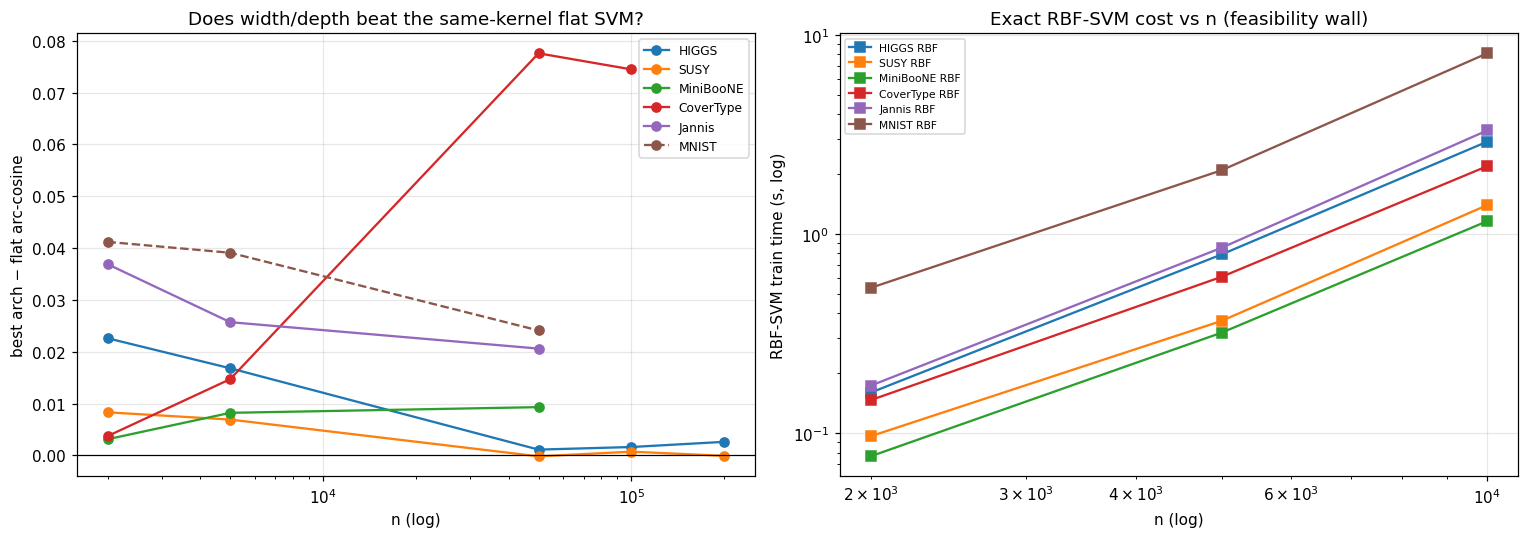

In [13]:
# Plot: architecture vs flat baseline across n, per dataset
fig,axes=plt.subplots(1,2,figsize=(14,5))
ax=axes[0]
for ds in DATASET_ORDER:
    g=HL[HL.dataset==ds].sort_values("n")
    if g.empty: continue
    style="--" if IS_CONTROL.get(ds) else "-"
    ax.plot(g.n,g.arch_minus_flat,marker="o",ls=style,label=ds)
ax.axhline(0,color="k",lw=.8); ax.set_xscale("log")
ax.set_xlabel("n (log)"); ax.set_ylabel("best arch − flat arc-cosine")
ax.set_title("Does width/depth beat the same-kernel flat SVM?"); ax.legend(fontsize=8)
# train-time wall: architecture vs RBF
ax=axes[1]
tt = df.groupby(["dataset","model"]).train_time_s.mean().reset_index()
for ds in DATASET_ORDER:
    g=df[(df.dataset==ds)&(df.model.str.contains("RBF",na=False))&(df.acc.notna())]
    gg=g.groupby("n_train").train_time_s.mean()
    if len(gg): ax.plot(gg.index,gg.values,marker="s",label=f"{ds} RBF")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("n (log)"); ax.set_ylabel("RBF-SVM train time (s, log)")
ax.set_title("Exact RBF-SVM cost vs n (feasibility wall)"); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig("fig_headline.png",bbox_inches="tight"); plt.show()

## 6. Insight checklist (fill from the tables/figures)

- **Complexity (§2):** which datasets are complex at the probe $n$? Where does exact RBF-SVM become infeasible?
- **Width (§3):** is best $m>1$ > $m=1$, and does the gain shrink with $n$ (regulariser fading)?
- **Depth × task (§4):** is the depth gain larger for multiclass than binary — the predicted split?
- **Depth × width (§4):** does the depth gain grow with $m$?
- **Earns complexity (§5):** does best arch beat flat arc-cosine, and on which datasets/$n$?

**Caveats to carry into the writeup:** report only gains beyond one seed std; the complexity probe is
scale-dependent (HIGGS/SUSY may read "not complex" at small probe $n$ yet separate at large $n$ where RBF
cannot run); MNIST is the simple control and should show little width/depth benefit.